<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Métodos de Ensamble: Bagging y Random Forests 🌲🌲🌲
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 09
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Science%20programming/09%20-%20Decision%20Trees/03_Metodos_Ensamble_Bagging_y_Random_Forests.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. ¿Qué es un Método de Ensamble? La Sabiduría de la Multitud 🧠

Un **método de ensamble (*ensemble method*)** es una estrategia de aprendizaje automático que combina múltiples modelos individuales simples —llamados **"bloques de construcción"** o **aprendices débiles (*weak learners*)**— con el fin de obtener un modelo único y altamente potente. Individualmente, estos modelos base pueden ofrecer predicciones mediocres o tener alta varianza, pero al articularse en equipo producen estimaciones notablemente más estables y precisas.

En este cuaderno exploramos dos de los ensambles más utilizados basados en árboles de decisión:
1. **Bagging (*Bootstrap Aggregating*)**
2. **Random Forests (*Bosques Aleatorios*)**

---
## 2. Bagging: Bootstrap + Aggregating 🎒

<div style="background: #eff6ff; border-left: 5px solid #3b82f6; border-radius: 6px; padding: 14px; margin: 16px 0;">
  <h4 style="margin-top: 0; color: #1e40af;">❓ Pregunta Clave: ¿De dónde proviene la palabra "Bagging"?</h4>
  <p>El término es un acrónimo formado por dos conceptos estadísticos fundamentales:</p>
  <ul>
    <li><b>Bootstrap:</b> Generamos múltiples conjuntos de entrenamiento mediante <i>remuestreo con reemplazo</i> a partir del dataset original. Entrenamos un árbol de decisión completo e independiente sobre cada muestra.</li>
    <li><b>AggregatING:</b> Para cualquier dato nuevo de entrada, combinamos o <i>promediamos</i> las predicciones de todos los árboles entrenados.</li>
  </ul>
  <p style="margin-bottom: 0; font-weight: bold; color: #1d4ed8;">Bagging = Bootstrap + AGGregatING</p>
</div>

### Fundamento Matemático de la Reducción de Varianza:
Dadas $B$ observaciones aleatorias independientes e idénticamente distribuidas, cada una con varianza $\sigma^2$, la varianza de la media muestral está dada por:
$$\text{Var}(\bar{X}) = \frac{\sigma^2}{B}$$
Es decir, **promediar un conjunto de estimadores reduce drásticamente la varianza**.

Si tuviésemos acceso a $B$ conjuntos de datos de entrenamiento independientes extraídos de la población real, entrenaríamos un modelo $\hat{f}^b(x)$ en cada uno y promediaríamos sus resultados:
$$\hat{f}_{ensamble}(x) = \frac{1}{B} \sum_{b=1}^B \hat{f}^b(x)$$

En la práctica sólo disponemos de **un único conjunto de entrenamiento**. La técnica **Bootstrap** soluciona esto extrayendo $B$ subconjuntos de tamaño $N$ mediante muestreo aleatorio con reemplazo. Entrenamos el $b$-ésimo árbol $\hat{f}^{*b}(x)$ sobre cada muestra bootstrap y agregamos sus predicciones:
$$\hat{f}_{bagging}(x) = \frac{1}{B} \sum_{b=1}^B \hat{f}^{*b}(x)$$

> 📌 **Propiedad Fundamental:** En Bagging, el número de árboles $B$ **no es un parámetro crítico de sobreajuste**. Entrenar un número muy grande de árboles (ej. $B = 500$ o $1000$) **no provoca sobreajuste (*overfitting*)**; simplemente se elige un $B$ suficientemente grande para que el error se estabilice.

---
## 3. Predicción en Bagging: El Arreglo de Ensamble y Votación Mayoritaria 📊

A continuación se recrea la estructura matricial de predicción conocida como el **Arreglo de Bagging (*Bagging Array*)**:


<div align="center" style="margin: 18px 0;">
  <img src="images/bagging_array.png" onerror="this.onerror=null; this.src='https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Science%20programming/09%20-%20Decision%20Trees/images/bagging_array.png';" width="660" alt="Diapositiva: Esquema Matricial del Arreglo de Bagging y Votación Mayoritaria" style="border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.12); max-width: 100%;"/>
</div>

### Esquema de Agregación Según el Tipo de Problema:
* **Regresión:** Se calcula el promedio aritmético simple de las predicciones continuas de los $B$ árboles.
* **Clasificación Binaria:** Se utiliza una regla de **votación mayoritaria (*majority voting*)**: la clase final es $1$ si la media de las predicciones supera el umbral del $50\%$ (`np.mean(predicciones, axis=1) > 0.5`).
* **Clasificación Multiclase:** Votación ponderada basada en las probabilidades predichas por cada árbol individual.

En Scikit-Learn, esto se implementa con la clase `BaggingClassifier` (o `BaggingRegressor`):

In [3]:
import os, sys, time, urllib.request
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (8.5, 4.5)
plt.rcParams['font.size'] = 10

# Función de utilidad para cargar datasets de forma segura (Local o Google Colab)
def load_dataset(filename, module_folder="09 - Decision Trees"):
    local_path = os.path.join(os.getcwd(), "data", filename)
    if os.path.exists(local_path):
        return local_path
    
    parent_path = os.path.join(os.getcwd(), "..", module_folder, "data", filename)
    if os.path.exists(parent_path):
        return parent_path

    raw_url = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Science%20programming/{module_folder.replace(' ', '%20')}/data/{filename}"
    os.makedirs("data", exist_ok=True)
    target_path = os.path.join("data", filename)
    if not os.path.exists(target_path):
        try:
            urllib.request.urlretrieve(raw_url, target_path)
        except Exception:
            fallbacks = {
                'spam.csv': 'https://raw.githubusercontent.com/datasets/machine-learning/master/spambase.csv'
            }
            if filename in fallbacks:
                urllib.request.urlretrieve(fallbacks[filename], target_path)
            else:
                raise
    return target_path

# Aseguramiento de funciones de apoyo
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print("🚀 Entorno configurado exitosamente para Métodos de Ensamble.")

🚀 Entorno configurado exitosamente para Métodos de Ensamble.


---
## 4. Medidas de Importancia de Variables en Bagging 📈

Una de las mayores ventajas de los árboles individuales es su diagrama visual altamente interpretable. Sin embargo, al combinar $B$ árboles mediante Bagging, **la interpretabilidad directa se pierde a favor de una precisión predictiva superior**.

Para recuperar la interpretabilidad global, calculamos la **importancia de variables** sumando la disminución total del índice de impureza (Gini en clasificación o MSE en regresión) acumulada en todas las divisiones donde participa cada variable, y promediándola entre los $B$ árboles del ensamble:

$$\text{Importancia Promedio}(X_j) = \frac{1}{B} \sum_{b=1}^B \text{Importancia}^{(b)}(X_j)$$

In [4]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

# Cargar dataset de ejemplo
X_iris, y_iris = load_iris(return_X_y=True)
nombres_atributos = load_iris().feature_names

# Entrenar un ensamble de Bagging
clasificador_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
clasificador_bagging.fit(X_iris, y_iris)

# Scikit-Learn no expone directamente feature_importances_ en BaggingClassifier,
# pero podemos calcularlo extrayendo los árboles individuales en estimators_:
importancias_bagging = np.mean([
    arbol.feature_importances_ for arbol in clasificador_bagging.estimators_
], axis=0)

df_importancias = pd.DataFrame({
    'Atributo': nombres_atributos,
    'Importancia Promedio': importancias_bagging
}).sort_values(by='Importancia Promedio', ascending=False)

print("Importancia promedio de variables calculada en el ensamble de Bagging:")
display(df_importancias)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=42)

Importancia promedio de variables calculada en el ensamble de Bagging:


,Atributo,Importancia Promedio
2,petal length (cm),0.500979
3,petal width (cm),0.476255
1,sepal width (cm),0.012063
0,sepal length (cm),0.010703


---
## 5. Implementación Paso a Paso de Bagging sobre el Dataset de Spam 📧

Para comprender a fondo la mecánica interna de Bagging, implementamos el procedimiento de forma explícita utilizando Pandas y NumPy sobre el dataset de detección de Spam:
1. Realizamos remuestreo con reemplazo (*bootstrapping*) con `data_train.sample(frac=1.0, replace=True)`.
2. Entrenamos $B = 100$ árboles de decisión independientes con profundidad máxima fija (`max_depth = 5`).
3. Almacenamos las predicciones de cada modelo en un arreglo de ensamble.
4. Analizamos la distribución de probabilidades predichas para correos legítimos vs. correos no deseados.
5. Aplicamos la regla de votación mayoritaria (`promedio > 0.5`).

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Carga del dataset de spam
archivo_spam = load_dataset('spam.csv', '09 - Decision Trees')
df_spam = pd.read_csv(archivo_spam, header=None)

# Renombrar columnas para claridad
num_cols = df_spam.shape[1] - 1
nombres_cols = [f'Caracteristica_{i+1}' for i in range(num_cols)] + ['Spam']
df_spam.columns = nombres_cols

# Partición de entrenamiento y prueba (70% / 30%)
datos_train, datos_test = train_test_split(
    df_spam, test_size=0.30, random_state=42, stratify=df_spam['Spam']
)

x_train = datos_train.drop(columns=['Spam'])
y_train = datos_train['Spam'].values
x_test  = datos_test.drop(columns=['Spam'])
y_test  = datos_test['Spam'].values

# 2. Verificación del efecto de remuestreo Bootstrap en la media de las variables
media_original = datos_train.mean(axis=0).to_frame('Media_Original').T
muestra_boot   = datos_train.sample(frac=1.0, replace=True, random_state=0)
media_boot     = muestra_boot.mean(axis=0).to_frame('Media_Bootstrap').T

print("Comparación estadística preliminar (primeras 6 variables):")
display(pd.concat([media_original.iloc[:, :6], media_boot.iloc[:, :6]]))

Comparación estadística preliminar (primeras 6 variables):


,Caracteristica_1,Caracteristica_2,Caracteristica_3,Caracteristica_4,Caracteristica_5,Caracteristica_6
Media_Original,0.107565,0.219578,0.275407,0.058829,0.314683,0.097298
Media_Bootstrap,0.103394,0.202401,0.267053,0.053205,0.318528,0.098761


DecisionTreeClassifier(max_depth=5, random_state=0)

DecisionTreeClassifier(max_depth=5, random_state=1)

DecisionTreeClassifier(max_depth=5, random_state=2)

DecisionTreeClassifier(max_depth=5, random_state=3)

DecisionTreeClassifier(max_depth=5, random_state=4)

...

<Axes: ylabel='Frequency'>

<Axes: ylabel='Frequency'>

Text(0.5, 0, 'Proporción Promedio de Votos a favor de Spam')

Text(0, 0.5, 'Densidad de Muestras')

Text(0.5, 1.0, 'Conjunto de Prueba: Separación de Clases por Ensamble')

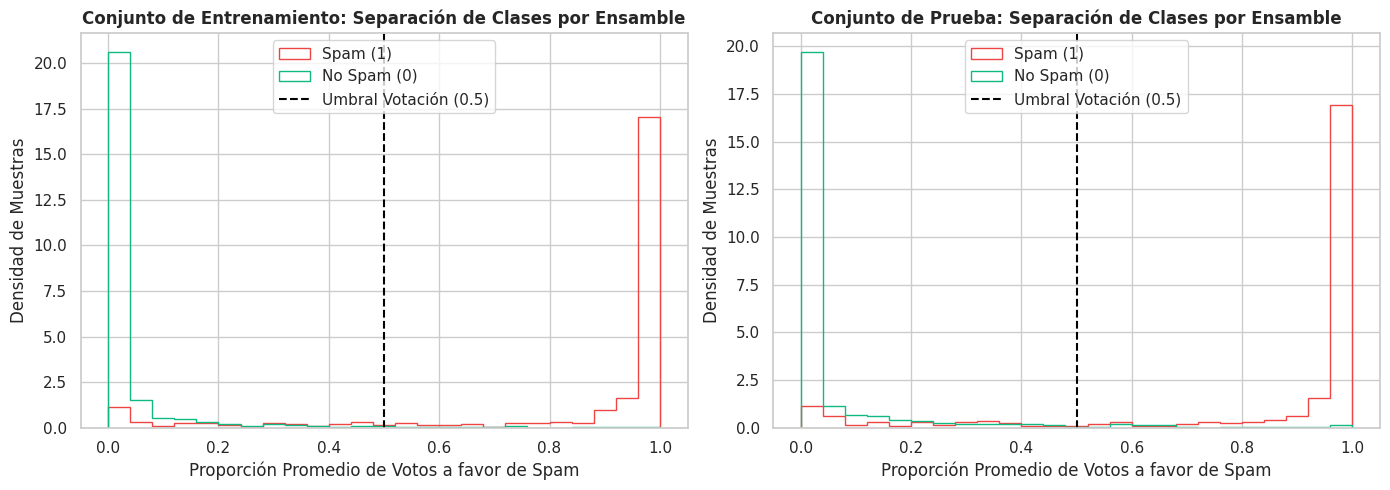

In [6]:
# 3. Ajuste iterativo de 100 árboles con remuestreo bootstrap
np.random.seed(0)
n_arboles = 100
profundidad_seleccionada = 5

predicciones_train = np.zeros(shape=(datos_train.shape[0], n_arboles))
predicciones_test  = np.zeros(shape=(datos_test.shape[0], n_arboles))

for i in range(n_arboles):
    # Muestra bootstrap con reemplazo
    temp_boot = datos_train.sample(frac=1.0, replace=True)
    boot_y = temp_boot['Spam']
    boot_X = temp_boot.drop(columns=['Spam'])
    
    arbol_individual = DecisionTreeClassifier(max_depth=profundidad_seleccionada, random_state=i)
    arbol_individual.fit(boot_X, boot_y)
    
    predicciones_train[:, i] = arbol_individual.predict(x_train)
    predicciones_test[:, i]  = arbol_individual.predict(x_test)

columnas_modelos = [f'Arbol_{i+1}' for i in range(n_arboles)]
df_pred_train = pd.DataFrame(predicciones_train, columns=columnas_modelos)
df_pred_test  = pd.DataFrame(predicciones_test,  columns=columnas_modelos)

# 4. Visualización de la distribución de votos de ensamble
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for (ax, titulo, preds, y_real) in [
    (axs[0], 'Conjunto de Entrenamiento', df_pred_train, y_train),
    (axs[1], 'Conjunto de Prueba', df_pred_test, y_test)
]:
    promedios = preds.mean(axis=1)
    promedios[y_real == 1].plot(kind='hist', density=True, histtype='step', bins=25, range=[0, 1], label='Spam (1)', lw=2.5, color='#ef4444', ax=ax)
    promedios[y_real == 0].plot(kind='hist', density=True, histtype='step', bins=25, range=[0, 1], label='No Spam (0)', lw=2.5, color='#10b981', ax=ax)
    ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Umbral Votación (0.5)')
    ax.set_xlabel('Proporción Promedio de Votos a favor de Spam')
    ax.set_ylabel('Densidad de Muestras')
    ax.set_title(f'{titulo}: Separación de Clases por Ensamble', fontweight='bold')
    ax.legend(loc='upper center')

plt.tight_layout()
plt.show()

In [7]:
# Función de agregación por votación mayoritaria
def obtener_prediccion_mayoritaria(df_pred):
    return (df_pred.mean(axis=1) > 0.5).astype(int)

pred_final_train = obtener_prediccion_mayoritaria(df_pred_train)
pred_final_test  = obtener_prediccion_mayoritaria(df_pred_test)

acc_bagging_train = accuracy_score(y_train, pred_final_train) * 100
acc_bagging_test  = accuracy_score(y_test,  pred_final_test) * 100

print("="*55)
print(f"Bagging Manual (100 árboles) - Exactitud en Entrenamiento: {acc_bagging_train:.2f}%")
print(f"Bagging Manual (100 árboles) - Exactitud en Prueba:        {acc_bagging_test:.2f}%")
print("="*55)

print("\nMatriz de Confusión sobre el Conjunto de Prueba:")
tabla_confusion = pd.crosstab(
    y_test, pred_final_test,
    rownames=['Clase Real'], colnames=['Predicción Ensamble'], margins=True
)
display(tabla_confusion)

Bagging Manual (100 árboles) - Exactitud en Entrenamiento: 93.39%
Bagging Manual (100 árboles) - Exactitud en Prueba:        91.75%

Matriz de Confusión sobre el Conjunto de Prueba:


Predicción Ensamble,0,1,All
Clase Real,,,
0,807,30,837
1,84,460,544
All,891,490,1381


---
## 6. Árboles y Bagging en el Contexto de Sesgo y Varianza ⚖️

La efectividad de Bagging se comprende a partir de la descomposición del error en **Sesgo y Varianza**:

  Diapositiva Teórica: El Compromiso Sesgo-Varianza
  A medida que aumenta la complejidad del modelo (por ejemplo, incrementando la profundidad <code>max_depth</code> de un árbol):
  
  El Sesgo al Cuadrado ($\text{Sesgo}^2$):</b> Disminuye sostenidamente. El modelo se vuelve más flexible y capaz de capturar patrones no lineales.
  La Varianza: Aumenta drásticamente. El modelo se vuelve hipersensible a las fluctuaciones aleatorias del conjunto de entrenamiento.
  El Error Total: Exhibe una curva clásica en forma de <i>U</i> con un punto óptimo de complejidad intermedia.
    $$\text{Error Total} = \text{Sesgo}^2 + \text{Varianza} + \text{Error Irreducible } (\sigma^2)$$




<div align="center" style="margin: 18px 0;">
  <img src="images/bias_variance.png" onerror="this.onerror=null; this.src='https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Science%20programming/09%20-%20Decision%20Trees/images/bias_variance.png';" width="480" alt="Diapositiva: Curva de Compromiso Sesgo-Varianza y Complejidad Óptima" style="border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.12); max-width: 100%;"/>
</div>

### Los Tres Regímenes de Ajuste:

<div align="center" style="margin: 18px 0;">
  <img src="images/fitting.png" onerror="this.onerror=null; this.src='https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Science%20programming/09%20-%20Decision%20Trees/images/fitting.png';" width="650" alt="Diapositiva: Regímenes de Ajuste - Subajuste, Ajuste Apropiado y Sobreajuste" style="border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.12); max-width: 100%;"/>
</div>


1. **Subajuste (*Underfitting*):** El modelo es demasiado rígido (árbol con `max_depth = 1` o `2`). No captura la estructura de los datos $\rightarrow$ **Alto Sesgo**.
2. **Ajuste Apropiado (*Appropriate Fitting*):** Captura las fronteras esenciales sin ajustarse al ruido $\rightarrow$ **Equilibrio Óptimo**.
3. **Sobreajuste (*Overfitting*):** Árbol no restringido que memoriza cada punto individual, creando fronteras erráticas $\rightarrow$ **Alta Varianza**.

> 💡 **¿Cuál es la magia de Bagging?** Bagging toma árboles deliberadamente profundos (que tienen **bajo sesgo** pero alta varianza) y utiliza el promedio bootstrap para **reducir drásticamente la varianza** sin empeorar el sesgo.

---
## 7. La Gran Debilidad de Bagging: El Algoritmo Goloso (*Greedy*) y la Correlación ⚠️

Si Bagging reduce la varianza de los árboles profundos, ¿por qué necesitamos **Random Forests**? La respuesta radica en la naturaleza **golosa (*greedy*)** del algoritmo de división de los árboles.

 Predictores Dominantes y Árboles Correlacionados</h3>
Imaginemos un proceso generador de datos donde tres variables $x_1, x_2, x_3$ se relacionan con el objetivo $y$:


  <img src="images/dep_predictors.png" onerror="this.onerror=null; this.src='https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Science%20programming/09%20-%20Decision%20Trees/images/dep_predictors.png';" width="540" alt="Diapositiva: Variable Dominante y Correlación de Árboles en Bagging" style="border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.12); max-width: 100%;"/>

  Aquí, $x_1$ es una <b>variable abrumadoramente dominante</b> con respecto a las demás.
  Dado que los árboles de decisión son heurísticas golosas (greedy) que siempre seleccionan la variable con mayor ganancia de información inmediata, <b>prácticamente todos los árboles del ensamble de Bagging elegirán $x_1$ como su nodo raíz

### Consecuencia Estadística de la Correlación:
Cuando las cantidades que promediamos están correlacionadas con coeficiente $\rho$, la varianza de su promedio ya **no** se reduce a $\sigma^2 / B$, sino a:

$$\text{Var}(\bar{X}) = \rho \sigma^2 + \frac{1 - \rho}{B} \sigma^2$$

A medida que aumentamos el número de árboles $B \to \infty$, el segundo término desaparece, ¡pero el término $\mathbf{\rho \sigma^2}$ persiste! Si los árboles son muy similares entre sí (alta correlación $\rho$), **Bagging se estanca y no logra reducir la varianza adicionalmente**.

---
## 8. Random Forest: La Solución Ingeniosa de Descorrelación 🌲🎲

Propuesto por Leo Breiman en 2001, **Random Forest (Bosques Aleatorios)** introduce una modificación sencilla pero brillante para resolver la debilidad de Bagging:

1. Al igual que en Bagging, se construyen $B$ árboles sobre muestras bootstrap de entrenamiento.
2. **La Gran Diferencia (*Submuestreo de Características*):** Cada vez que se evalúa una división en cualquier nodo de cualquier árbol, el algoritmo **sólo tiene permitido considerar un subconjunto aleatorio de variables candidatas** de tamaño $m$, extraído del total de $p$ variables disponibles.

Por convención estándar en Scikit-Learn:
* **Clasificación:** $m = \sqrt{p}$ (`max_features='sqrt'`)
* **Regresión:** $m = \frac{p}{3}$ o $1.0$ (`max_features=1.0` o `max_features='sqrt'`)

> 💡 **¿Por qué funciona esta restricción?** Al impedir que la mayoría de los predictores sean considerados en cada división, la variable dominante $x_1$ **no puede participar en todas las divisiones**. Esto obliga al algoritmo a explorar predictores alternativos ($x_2, x_3$), logrando que los árboles sean **estadísticamente disímiles y descorrelacionados** (minimizando $\rho$).

In [8]:
from sklearn.ensemble import RandomForestClassifier

# Número de variables a considerar (p/2 o sqrt(p))
p_features = x_train.shape[1]
n_estimadores = int(p_features / 2)
profundidad_base = 7

# 1. Random Forest Estándar
modelo_rf = RandomForestClassifier(
    n_estimators=n_estimadores, max_depth=profundidad_base, random_state=42, n_jobs=-1
)
modelo_rf.fit(x_train, y_train)
acc_rf_train = accuracy_score(y_train, modelo_rf.predict(x_train)) * 100
acc_rf_test  = accuracy_score(y_test,  modelo_rf.predict(x_test))  * 100

# 2. Random Forest Más Profundo (Deep Random Forest)
profundidad_profunda = profundidad_base + 20  # depth = 27
modelo_rf_profundo = RandomForestClassifier(
    n_estimators=n_estimadores, max_depth=profundidad_profunda, random_state=42, n_jobs=-1
)
modelo_rf_profundo.fit(x_train, y_train)
acc_rf_prof_train = accuracy_score(y_train, modelo_rf_profundo.predict(x_train)) * 100
acc_rf_prof_test  = accuracy_score(y_test,  modelo_rf_profundo.predict(x_test))  * 100

# 3. Árbol Simple de Referencia
arbol_simple = DecisionTreeClassifier(max_depth=profundidad_base, random_state=42)
arbol_simple.fit(x_train, y_train)
acc_arbol_train = accuracy_score(y_train, arbol_simple.predict(x_train)) * 100
acc_arbol_test  = accuracy_score(y_test,  arbol_simple.predict(x_test))  * 100

# Comparativa global de desempeño
resumen_modelos = pd.DataFrame({
    'Modelo': [
        'Árbol de Decisión Simple (depth=7)',
        'Bagging Classifier (100 árboles, depth=5)',
        'Random Forest (depth=7)',
        'Random Forest Profundo (depth=27)'
    ],
    'Exactitud Entrenamiento (%)': [acc_arbol_train, acc_bagging_train, acc_rf_train, acc_rf_prof_train],
    'Exactitud Prueba (%)':        [acc_arbol_test,  acc_bagging_test,  acc_rf_test,  acc_rf_prof_test]
})

print("📊 Comparativa de Modelos sobre el Dataset de Spam:")
display(resumen_modelos.round(2))

RandomForestClassifier(max_depth=7, n_estimators=28, n_jobs=-1, random_state=42)

RandomForestClassifier(max_depth=27, n_estimators=28, n_jobs=-1,
                       random_state=42)

DecisionTreeClassifier(max_depth=7, random_state=42)

📊 Comparativa de Modelos sobre el Dataset de Spam:


,Modelo,Exactitud Entrenamiento (%),Exactitud Prueba (%)
0,Árbol de Decisión Simple (depth=7),94.13,90.88
1,"Bagging Classifier (100 árboles, depth=5)",93.39,91.75
2,Random Forest (depth=7),95.09,93.41
3,Random Forest Profundo (depth=27),99.88,95.29


---
## 9. Inspección de la Estructura Interna: ¿Cómo Diversifican los Nodos? 🔬

El atributo `.estimators_` de `RandomForestClassifier` almacena la lista de estimadores individuales `DecisionTreeClassifier` que conforman el bosque. Cada árbol posee un atributo `.tree_` que permite auditar el número de nodos (`node_count`), las variables elegidas y las impurezas.

A continuación, comparamos la distribución de impureza y la variable seleccionada en el **nodo raíz (nodo 0)** entre Random Forest y Bagging para verificar empíricamente la descorrelación:

Conteo de nodos del primer árbol de Random Forest: 105 nodos


<Axes: xlabel='count', ylabel='Variable'>

Text(0.5, 1.0, 'Bagging: Variables Elegidas en el Nodo Raíz\n(Poca diversidad: variable dominante concentra las divisiones)')

Text(0.5, 0, 'Frecuencia de Selección')

<Axes: xlabel='count', ylabel='Variable'>

Text(0.5, 1.0, 'Random Forest: Variables Elegidas en el Nodo Raíz\n(Gran diversidad: selección aleatoria descorrelaciona los árboles)')

Text(0.5, 0, 'Frecuencia de Selección')

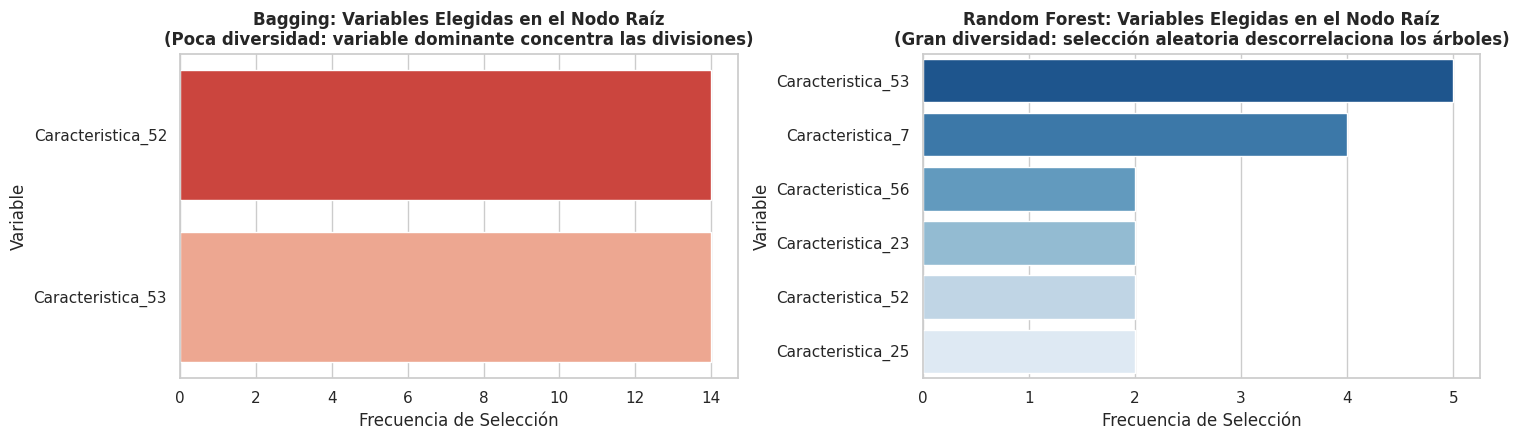

In [9]:
from sklearn.ensemble import BaggingClassifier

# Modelo de Bagging para contrastar nodo a nodo con Random Forest
modelo_bagging_sk = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=profundidad_base),
    n_estimators=n_estimadores,
    random_state=42
).fit(x_train, y_train)

print(f"Conteo de nodos del primer árbol de Random Forest: {modelo_rf.estimators_[0].tree_.node_count} nodos")

def extraer_info_nodo_raiz(modelo, nombres_vars, n_nodo=0):
    impurezas, variables = [], []
    for est in modelo.estimators_:
        arbol_obj = est.tree_
        idx_var = arbol_obj.feature[n_nodo]
        imp = arbol_obj.impurity[n_nodo]
        impurezas.append(imp)
        variables.append(nombres_vars[idx_var] if idx_var >= 0 else 'Hoja')
    return pd.DataFrame({'Variable': variables, 'Impureza': impurezas})

df_nodo_rf  = extraer_info_nodo_raiz(modelo_rf, x_train.columns)
df_nodo_bag = extraer_info_nodo_raiz(modelo_bagging_sk, x_train.columns)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

sns.countplot(y='Variable', data=df_nodo_bag, ax=axes[0], palette='Reds_r', order=df_nodo_bag['Variable'].value_counts().index[:6])
axes[0].set_title('Bagging: Variables Elegidas en el Nodo Raíz\n(Poca diversidad: variable dominante concentra las divisiones)', fontweight='bold')
axes[0].set_xlabel('Frecuencia de Selección')

sns.countplot(y='Variable', data=df_nodo_rf, ax=axes[1], palette='Blues_r', order=df_nodo_rf['Variable'].value_counts().index[:6])
axes[1].set_title('Random Forest: Variables Elegidas en el Nodo Raíz\n(Gran diversidad: selección aleatoria descorrelaciona los árboles)', fontweight='bold')
axes[1].set_xlabel('Frecuencia de Selección')

plt.tight_layout()
plt.show()

---
## 10. Importancia Relativa de Variables en Random Forest 🏆

En Random Forest, la importancia de cada característica se calcula de manera nativa como la **disminución promedio ponderada de impureza de Gini** producida por esa característica a lo largo de todos los árboles del bosque.

A continuación, escalamos las importancias a una escala relativa de $0$ a $100$ y graficamos las 15 características más influyentes en la detección de spam:

<Figure size 900x650 with 0 Axes>

<BarContainer object of 15 artists>

([<matplotlib.axis.YTick at 0x7fdb460d8cd0>,
 [Text(0, 0.5, 'Caracteristica_46'),
  Text(0, 1.5, 'Caracteristica_24'),
  Text(0, 2.5, 'Caracteristica_23'),
  Text(0, 3.5, 'Caracteristica_26'),
  Text(0, 4.5, 'Caracteristica_5'),
  Text(0, 5.5, 'Caracteristica_19'),
  Text(0, 6.5, 'Caracteristica_25'),
  Text(0, 7.5, 'Caracteristica_55'),
  Text(0, 8.5, 'Caracteristica_21'),
  Text(0, 9.5, 'Caracteristica_57'),
  Text(0, 10.5, 'Caracteristica_16'),
  Text(0, 11.5, 'Caracteristica_56'),
  Text(0, 12.5, 'Caracteristica_7'),
  Text(0, 13.5, 'Caracteristica_52'),
  Text(0, 14.5, 'Caracteristica_53')])

Text(0.5, 0, 'Importancia Relativa (Escala 0 - 100)')

Text(0.5, 1.0, 'Top 15 Características Más Influyentes en Random Forest (Spam)')

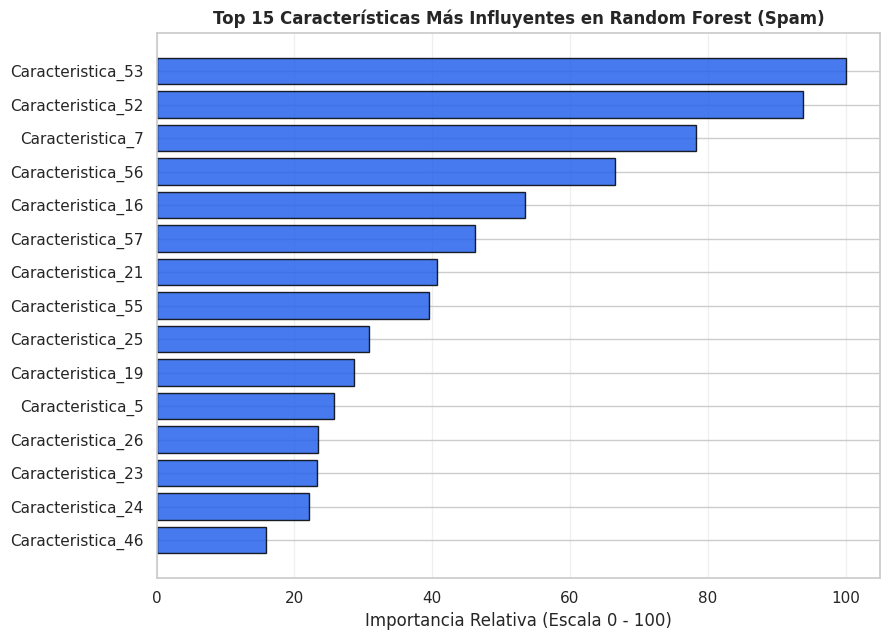

In [10]:
# 1. Extraer importancias del mejor modelo de Random Forest
importancias_crudas = modelo_rf_profundo.feature_importances_

# 2. Reescalar para que la característica más importante tenga un valor de 100
importancias_relativas = 100.0 * (importancias_crudas / importancias_crudas.max())

# 3. Ordenar índices de menor a mayor para graficar horizontalmente
indices_ordenados = np.argsort(importancias_relativas)[-15:]  # Top 15 variables

# 4. Graficar barras horizontales
posicion = np.arange(indices_ordenados.shape[0]) + 0.5

plt.figure(figsize=(9, 6.5))
plt.barh(posicion, importancias_relativas[indices_ordenados], align='center', color='#2563eb', alpha=0.85, edgecolor='black')
plt.yticks(posicion, x_train.columns[indices_ordenados])
plt.xlabel('Importancia Relativa (Escala 0 - 100)')
plt.title('Top 15 Características Más Influyentes en Random Forest (Spam)', fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
##### 🛠️ Práctica Guiada: Comparación de Curvas de Validación Cruzada en Cáncer de Mama

**Objetivo:** Evaluar el impacto de la profundidad del árbol (`max_depth`) y el número de estimadores (`n_estimators`) en el dataset de diagnóstico de cáncer de mama (*Breast Cancer Wisconsin*), contrastando el comportamiento de un **Árbol Simple** frente a **Random Forest** mediante validación cruzada.

**Preguntas Clave para el Análisis:**
1. *¿Por qué la exactitud de Random Forest no se degrada a medida que los árboles se hacen más profundos, a diferencia del árbol individual?*
2. *¿Cuáles son las dos fuentes de estocasticidad (aleatoriedad) que hacen que Random Forest sea tan robusto?* (1. Muestreo bootstrap de filas; 2. Submuestreo aleatorio de columnas en cada división).

<Figure size 1000x450 with 0 Axes>

Text(0.5, 0, 'Profundidad Máxima del Árbol (max_depth)')

Text(0, 0.5, 'Exactitud Promedio en Validación Cruzada')

Text(0.5, 1.0, 'Variación de la Exactitud con la Profundidad: Árbol vs. Random Forest')

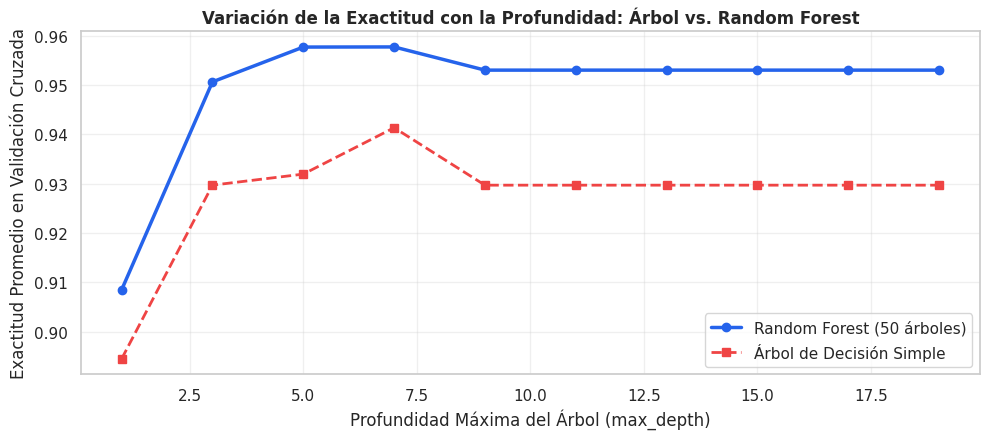

In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# 1. Carga y estandarización del dataset de cáncer de mama
datos_cancer = load_breast_cancer()
scaler = StandardScaler()
X_cancer_sc = scaler.fit_transform(datos_cancer.data)
y_cancer    = datos_cancer.target

X_can_tr, X_can_ts, y_can_tr, y_can_ts = train_test_split(
    X_cancer_sc, y_cancer, test_size=0.25, random_state=42, stratify=y_cancer
)

# 2. Evaluación de desempeño con CV según la profundidad (depth)
rango_profundidades = range(1, 20, 2)
scores_cv_arbol = []
scores_cv_rf    = []

for d in rango_profundidades:
    m_tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    m_rf   = RandomForestClassifier(n_estimators=50, max_depth=d, random_state=42, n_jobs=-1)
    
    score_t = cross_val_score(m_tree, X_can_tr, y_can_tr, cv=5, scoring='accuracy').mean()
    score_r = cross_val_score(m_rf,   X_can_tr, y_can_tr, cv=5, scoring='accuracy').mean()
    
    scores_cv_arbol.append(score_t)
    scores_cv_rf.append(score_r)

# 3. Gráfico de curvas de validación cruzada
plt.figure(figsize=(10, 4.5))
plt.plot(list(rango_profundidades), scores_cv_rf,    'o-', color='#2563eb', lw=2.5, label='Random Forest (50 árboles)')
plt.plot(list(rango_profundidades), scores_cv_arbol, 's--', color='#ef4444', lw=2.0, label='Árbol de Decisión Simple')
plt.xlabel('Profundidad Máxima del Árbol (max_depth)')
plt.ylabel('Exactitud Promedio en Validación Cruzada')
plt.title('Variación de la Exactitud con la Profundidad: Árbol vs. Random Forest', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. Limitaciones de Random Forest y Resumen del Cuaderno 📌

### ¿Cuándo puede sobreajustar o fallar un Random Forest?
1. **Presencia Excesiva de Ruido:** Si el conjunto de datos tiene una cantidad masiva de características espurias o completamente independientes del objetivo y muy pocas informativas, las divisiones aleatorias seleccionarán frecuentemente predictores ruidosos, degradando el ensamble.
2. **Pérdida de Interpretabilidad:** Un ensamble de cientos de árboles no puede expresarse como un conjunto único de reglas lógicas legibles por humanos (actúa como una "caja negra").
3. **Incapacidad de Extrapolación:** Al estar basados en árboles, no pueden predecir valores continuos fuera del rango mínimo y máximo observado en el entrenamiento.

### Conclusiones Principales:
* **Bagging** reduce la varianza de estimadores complejos mediante muestreo bootstrap con reemplazo y agregación de predicciones.
* **Random Forest** supera la correlación intrínseca de Bagging restringiendo la búsqueda de divisiones a subconjuntos aleatorios de características ($m \approx \sqrt{p}$).
* Las dos fuentes de aleatoriedad (muestreo de filas + submuestreo de columnas) proporcionan una notable resistencia al sobreajuste aun cuando los árboles individuales sean muy profundos.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>